In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
Precipitation = pd.read_csv("/Users/Brenn/OneDrive/Documents/Wren/Data Science/DS Foundatinos/Weather/clean_wlafayette_seattle.csv")

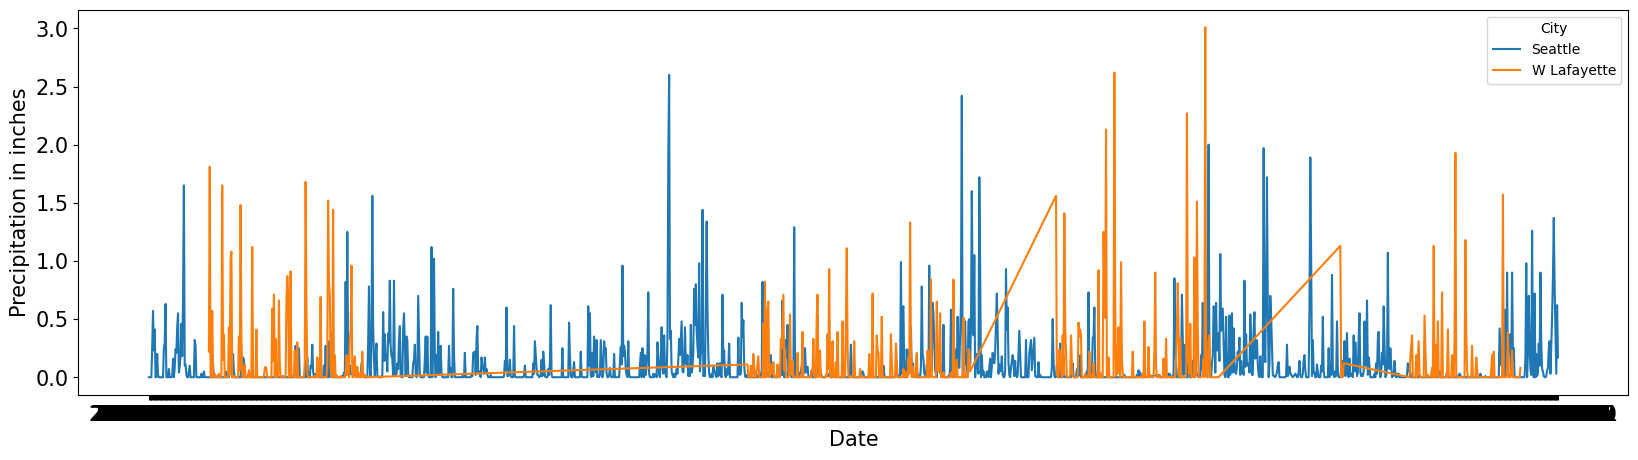

In [18]:
#Conduct Line plot of the cities against each other to see precipitation
plt.figure(figsize=(20,5))
sns.lineplot(data=Precipitation, x='Date', y='Precipitation', hue='City')
plt.xlabel('Date', fontsize=15)
plt.ylabel('Precipitation in inches', fontsize=15)
plt.tick_params(labelsize = 15)
plt.show()

In [20]:
#Description with groupby city
Precipitation[['City', 'Precipitation']].groupby('City').describe()

Precipitation                                                
                    count      mean       std  min  25%   50%   75%   max
City                                                                     
Seattle            1636.0  0.111852  0.248635  0.0  0.0  0.01  0.11  2.60
W Lafayette         788.0  0.128668  0.325658  0.0  0.0  0.00  0.08  3.01

In [22]:
#Bar chaart of mean daily precipitation
Precipitation[['City', 'Precipitation']].groupby('City').mean()

,Precipitation
City,
Seattle,0.111852
W Lafayette,0.128668


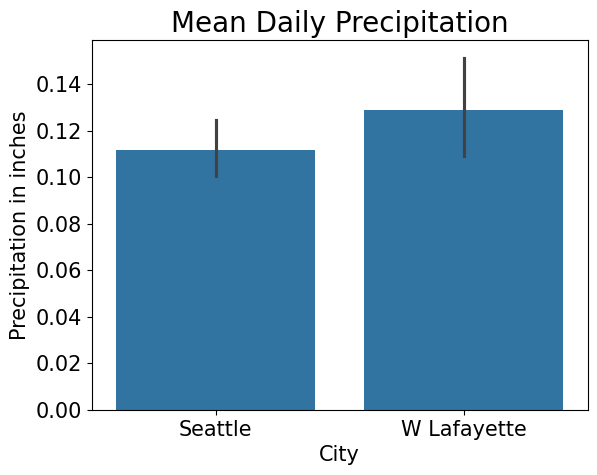

In [26]:
sns.barplot(data=Precipitation, x='City', y='Precipitation')
plt.xlabel('City', fontsize=15)
plt.ylabel('Precipitation in inches', fontsize=15)
plt.title('Mean Daily Precipitation', fontsize=20)
plt.tick_params(labelsize=15)
plt.show()

In [28]:
#What does errorbar represent?
sns.barplot?

Signature:
sns.barplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    order=None,
    hue_order=None,
    estimator='mean',
    errorbar=('ci', 95),
    n_boot=1000,
    seed=None,
    units=None,
    weights=None,
    orient=None,
    color=None,
    palette=None,
    saturation=0.75,
    fill=True,
    hue_norm=None,
    width=0.8,
    dodge='auto',
    gap=0,
    log_scale=None,
    native_scale=False,
    formatter=None,
    legend='auto',
    capsize=0,
    err_kws=None,
    ci=<deprecated>,
    errcolor=<deprecated>,
    errwidth=<deprecated>,
    ax=None,
    **kwargs,
)
Docstring:
Show point estimates and errors as rectangular bars.

A bar plot represents an aggregate or statistical estimate for a numeric
variable with the height of each rectangle and indicates the uncertainty
around that estimate using an error bar. Bar plots include 0 in the
axis range, and they are a good choice when 0 is a meaningful value
for the variable to take.

See the :ref:`tutorial 

In [34]:
#Adding Month Column
Precipitation['Month'] = pd.DatetimeIndex(Precipitation['Date']).month
Precipitation.head()

,Date,City,Precipitation,Day_of_Year,Month
0,2018-01-01,Seattle,0.00,1,1
1,2018-01-02,Seattle,0.00,2,1
2,2018-01-03,Seattle,0.00,3,1
3,2018-01-04,Seattle,0.00,4,1
4,2018-01-05,Seattle,0.25,5,1


In [38]:
Precipitation['Month'].unique()

array([ 1,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  2])

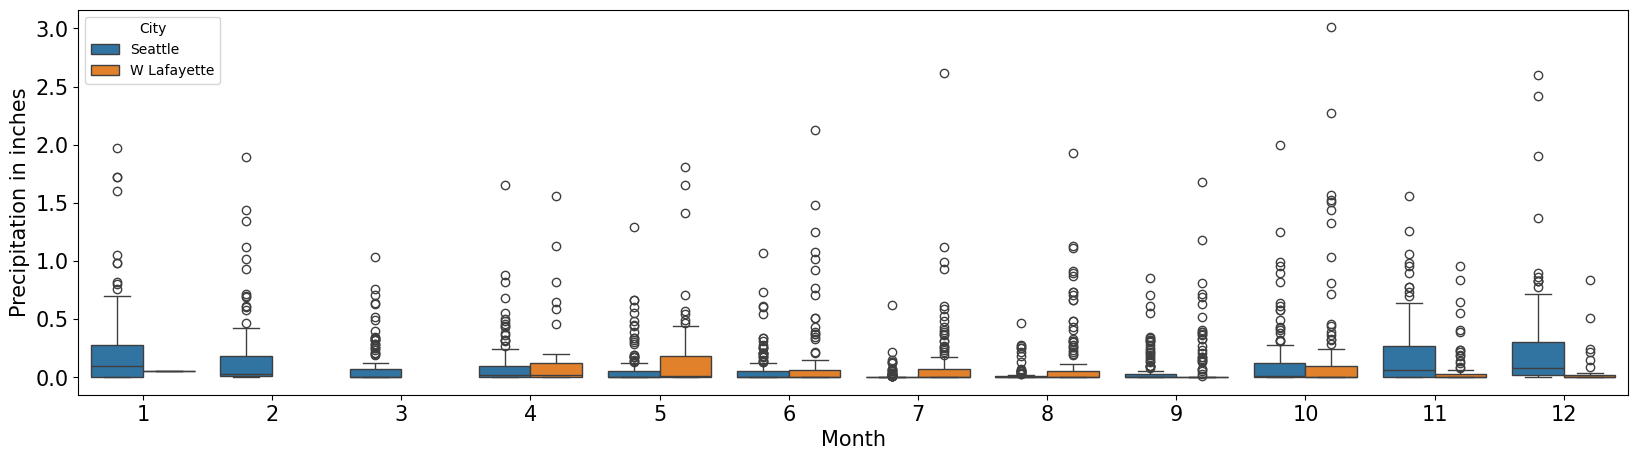

In [40]:
#Create Boxplot using Month instead of day
plt.figure(figsize=(20,5))
sns.boxplot(data=Precipitation, x="Month", y="Precipitation", hue='City')
plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation in inches', fontsize=15)
plt.tick_params(labelsize=15)
plt.show()

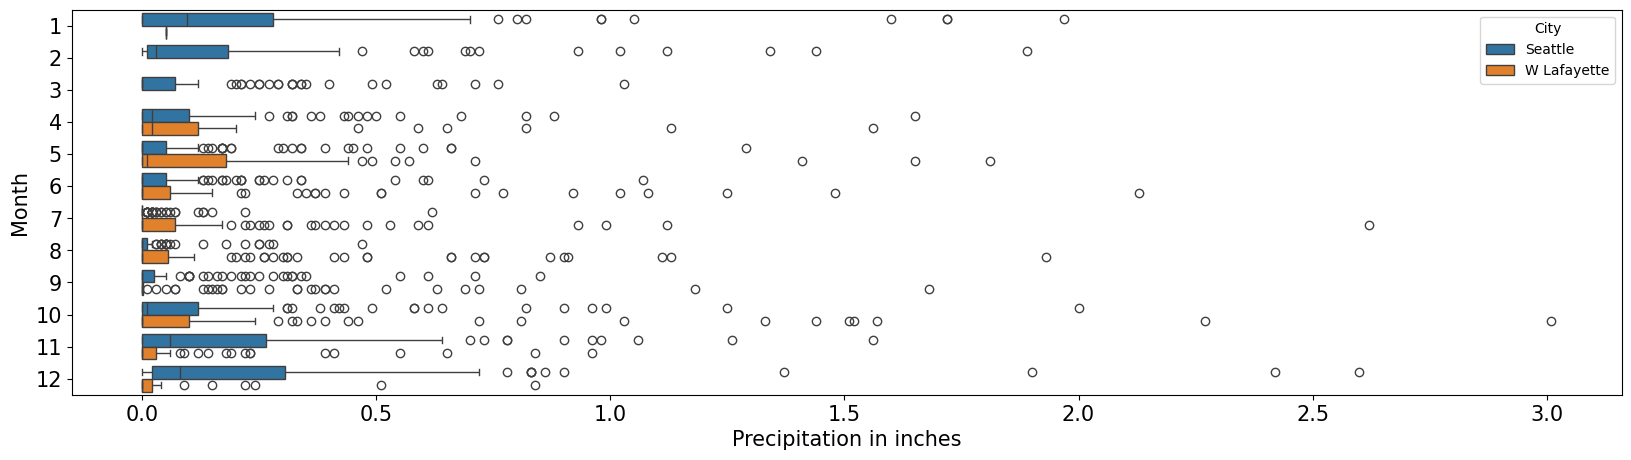

In [42]:
#Adjust orientation of boxplot
plt.figure(figsize=(20,5))
sns.boxplot(data=Precipitation, x="Precipitation", y="Month", hue='City', orient='h')
plt.xlabel('Precipitation in inches', fontsize=15)
plt.ylabel('Month', fontsize=15)
plt.tick_params(labelsize=15)
plt.show()

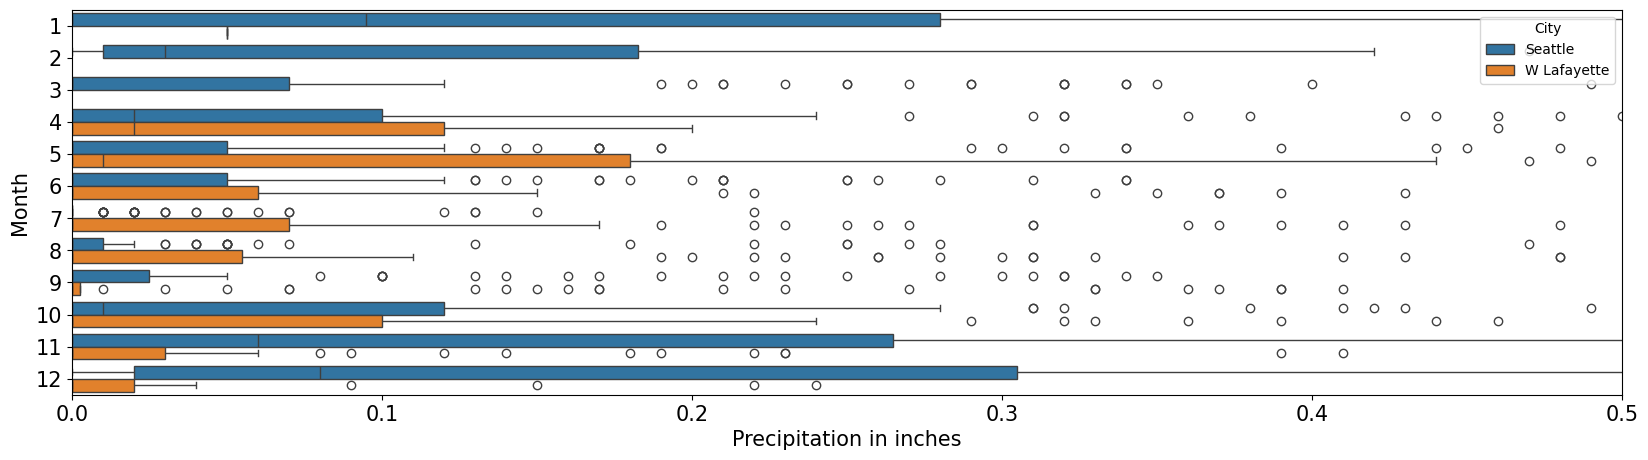

In [46]:
#zoom in on the data by applying a limit
plt.figure(figsize=(20,5))
sns.boxplot(data=Precipitation, x="Precipitation", y="Month", hue='City', orient='h')
plt.xlabel('Precipitation in inches', fontsize=15)
plt.ylabel('Month', fontsize=15)
plt.xlim(0,0.5)
plt.tick_params(labelsize=15)
plt.show()

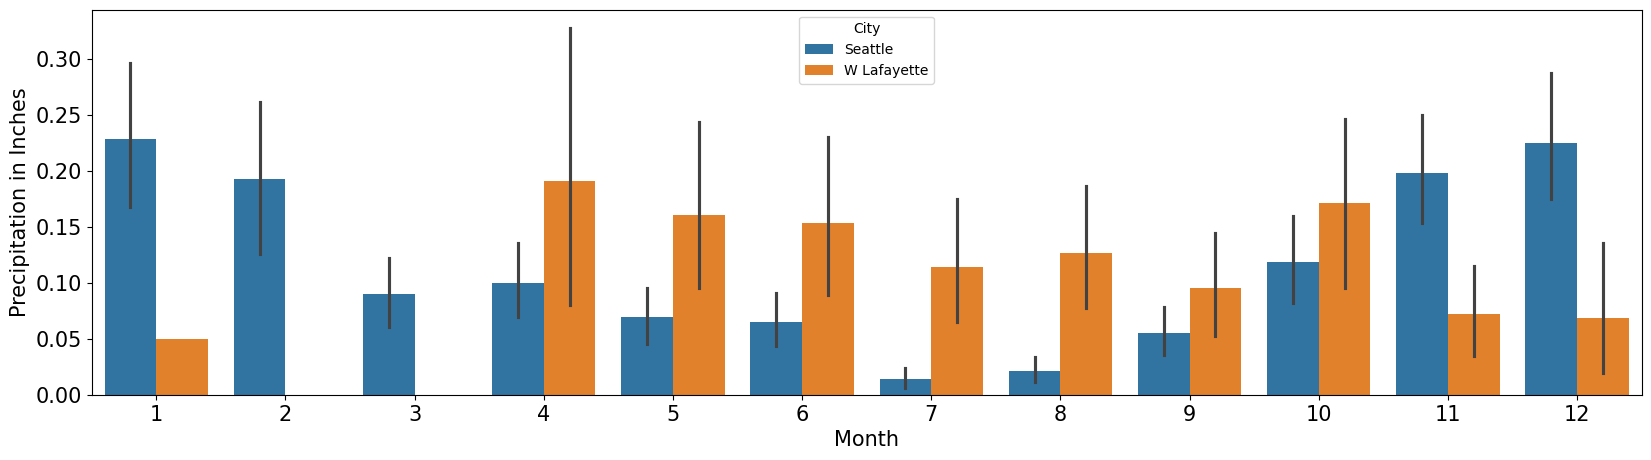

In [48]:
#Plot mean precipitation per month
plt.figure(figsize=(20,5))
sns.barplot(data=Precipitation, x='Month', y='Precipitation', hue='City')
plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation in Inches', fontsize=15)
plt.tick_params(labelsize=15)
plt.show()

In [50]:
#Determine mean by city and month
Precipitation[['Month', 'Precipitation', 'City']].groupby(['City','Month']).mean()

Precipitation
City        Month               
Seattle     1           0.228629
            2           0.192935
            3           0.089917
            4           0.099437
            5           0.069161
            6           0.064653
            7           0.013919
            8           0.021550
            9           0.055252
            10          0.118452
            11          0.197879
            12          0.224903
W Lafayette 1           0.050000
            2                NaN
            3                NaN
            4           0.190606
            5           0.160380
            6           0.153333
            7           0.114153
            8           0.126855
            9           0.095268
            10          0.170976
            11          0.072078
            12          0.068710

In [52]:
Precipitation['Any Precipitation'] = Precipitation['Precipitation']>0

In [54]:
Precipitation.head()

,Date,City,Precipitation,Day_of_Year,Month,Any Precipitation
0,2018-01-01,Seattle,0.00,1,1,False
1,2018-01-02,Seattle,0.00,2,1,False
2,2018-01-03,Seattle,0.00,3,1,False
3,2018-01-04,Seattle,0.00,4,1,False
4,2018-01-05,Seattle,0.25,5,1,True


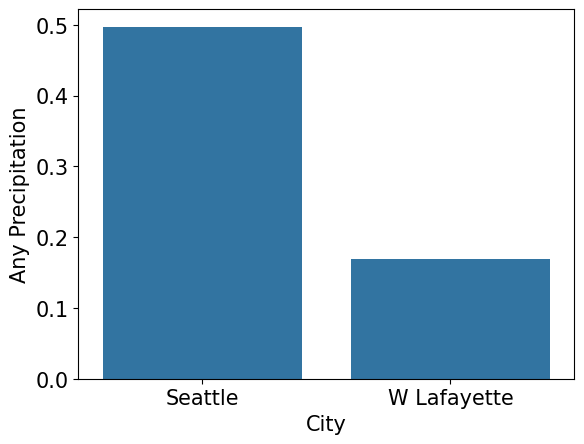

In [60]:
#Proportion of days with any precipitation
sns.barplot(data=Precipitation, x='City', y='Any Precipitation', errorbar=None)
plt.xlabel('City', fontsize=15)
plt.ylabel('Any Precipitation', fontsize=15)
plt.tick_params(labelsize=15)
plt.show()

In [62]:
#Conduct Statistical Test
from scipy import stats

In [68]:
significance_level = 0.05
significantly_different = np.zeros(12)
for Month in range(1,13):
    seadata=Precipitation.loc[(Precipitation['City']=='Seattle') & (Precipitation['Month']==Month), 'Precipitation']
    wlafdata=Precipitation.loc[(Precipitation['City']=='W Lafayette') & (Precipitation['Month']==Month), 'Precipitation']
    t_statistic, pvalue = stats.ttest_ind(seadata, wlafdata, equal_var=False)
    if pvalue< significance_level:
        significantly_different[Month-1]=1
    print(f"Month {Month}:")
    print(f" t_statistic = {t_statistic:.2f}")
    print(f" pvalue t test = {pvalue:.3f}")
    

Month 1:
 t_statistic = nan
 pvalue t test = nan
Month 2:
 t_statistic = nan
 pvalue t test = nan
Month 3:
 t_statistic = nan
 pvalue t test = nan
Month 4:
 t_statistic = nan
 pvalue t test = nan
Month 5:
 t_statistic = nan
 pvalue t test = nan
Month 6:
 t_statistic = nan
 pvalue t test = nan
Month 7:
 t_statistic = nan
 pvalue t test = nan
Month 8:
 t_statistic = nan
 pvalue t test = nan
Month 9:
 t_statistic = nan
 pvalue t test = nan
Month 10:
 t_statistic = nan
 pvalue t test = nan
Month 11:
 t_statistic = nan
 pvalue t test = nan
Month 12:
 t_statistic = nan
 pvalue t test = nan
